오버피팅 발생 및 해결 예제 코드
- MNIST 데이터셋을 사용하여 오버피팅을 의도적으로 발생시키고, 이후에 다양한 기법들을 적용하여 오버피팅을 해결하는 과정

1. 필요한 라이브러리 및 데이터 로드

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt

# 데이터 변환 및 로드
# UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release.
# Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
])

# 학습 데이터셋 (일부만 사용하여 오버피팅 유도)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset_indices = torch.arange(0, 2000)  # 학습 데이터 60000개 중 학습 데이터 2000개만 사용
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)

# 테스트 데이터셋
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

2. 기본 모델 정의 (오버피팅 발생 모델)

In [10]:
class OverfittingNet(nn.Module):
    def __init__(self):     # 정의부분, 공간만 확보
        super(OverfittingNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(1*28*28, 2048)   # 결과값 512와 다음 Layer의 입력값과 같아야 한다.
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(2048, 1024)   # 결과값 256와 다음 Layer의 입력값과 같아야 한다.
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(1024, 512)      # 결과값 128와 다음 Layer의 입력값과 같아야 한다.
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(512, 10)

    def forward(self, x):       # 실행 부분
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)  # CrossEntropyLoss()에 내장되어 있어 softmax() 미실행
        return x

# 모델, 손실 함수, 옵티마이저 정의
model = OverfittingNet()

criterion = nn.CrossEntropyLoss()   # softmax() 실행

optimizer = optim.SGD(model.parameters(), lr=0.01)      # 확룰적 경사하강법 SGD 사용

3. 학습 및 평가 함수 정의

In [17]:
# 학습 함수
def train(model, loader, optimizer, criterion):     # Batch size 개수만큼 호출, 1에폭당 5번 호출
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# 평가 함수
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy

4. 오버피팅 발생 확인

Epoch [1/100] - Train Loss: 0.0864, Test Loss: 0.3875, Accuracy: 89.01%
Epoch [2/100] - Train Loss: 0.0877, Test Loss: 0.3906, Accuracy: 89.01%
Epoch [3/100] - Train Loss: 0.0859, Test Loss: 0.3864, Accuracy: 89.25%
Epoch [4/100] - Train Loss: 0.0846, Test Loss: 0.3881, Accuracy: 89.33%
Epoch [5/100] - Train Loss: 0.0819, Test Loss: 0.3863, Accuracy: 89.24%
Epoch [6/100] - Train Loss: 0.0815, Test Loss: 0.3866, Accuracy: 89.24%
Epoch [7/100] - Train Loss: 0.0835, Test Loss: 0.3996, Accuracy: 89.17%
Epoch [8/100] - Train Loss: 0.0815, Test Loss: 0.3956, Accuracy: 89.14%
Epoch [9/100] - Train Loss: 0.0800, Test Loss: 0.3844, Accuracy: 89.34%
Epoch [10/100] - Train Loss: 0.0767, Test Loss: 0.3898, Accuracy: 89.16%
Epoch [11/100] - Train Loss: 0.0755, Test Loss: 0.3906, Accuracy: 89.25%
Epoch [12/100] - Train Loss: 0.0770, Test Loss: 0.3914, Accuracy: 89.16%
Epoch [13/100] - Train Loss: 0.0722, Test Loss: 0.3901, Accuracy: 89.31%
Epoch [14/100] - Train Loss: 0.0718, Test Loss: 0.3883, Accu

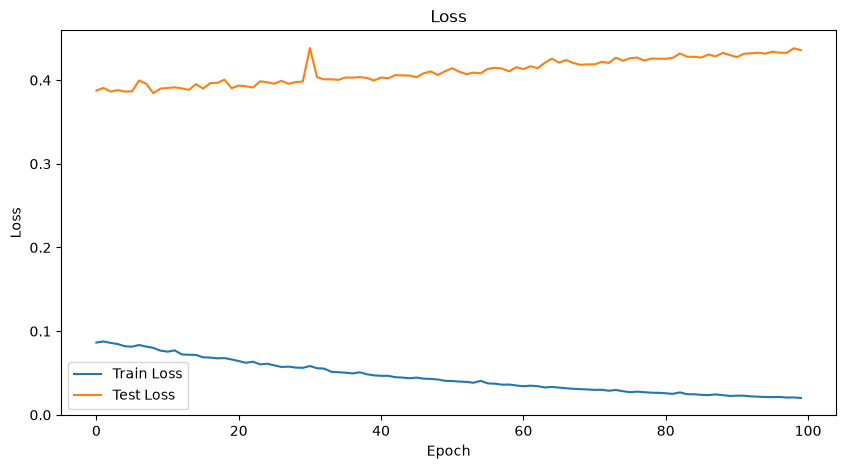

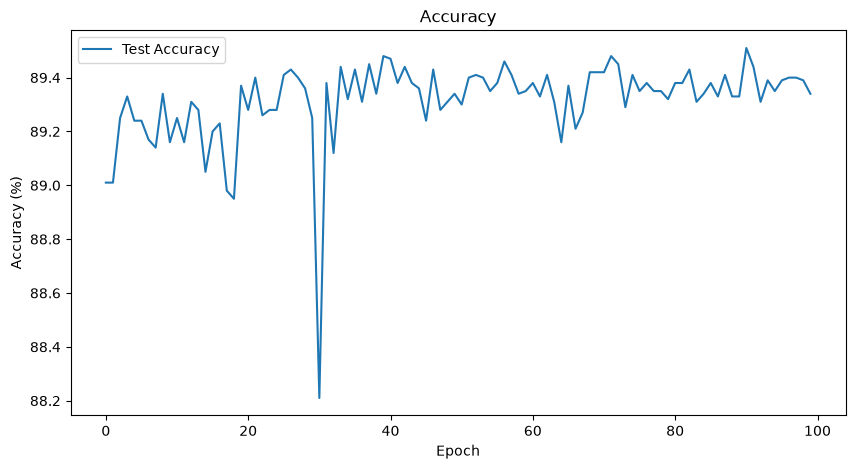

In [18]:
# 학습 및 평가 기록을 저장할 리스트
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 100
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

5. 오버피팅 해결 방법 적용

A. 데이터 증강 적용

In [ ]:
# 데이터 변환에 데이터 증강 기법 추가
# UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release.
# Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
transform_augmented = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
])

# 데이터셋 및 로더 재정의
train_dataset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
train_subset_augmented = torch.utils.data.Subset(train_dataset_augmented, subset_indices)
train_loader_augmented = torch.utils.data.DataLoader(train_subset_augmented, batch_size=64, shuffle=True)

B. 드롭아웃 및 배치 정규화 적용한 모델 정의

In [19]:
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5) # 하이퍼파라미터
        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)  # 하이퍼파라미터
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5) # 하이퍼파라미터
        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)  # 하이퍼파라미터
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.relu3(self.bn3(self.layer3(x)))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 재정의 (L2 정규화 적용)
model_improved = ImprovedNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_improved.parameters(), lr=0.01, weight_decay=0.001)

C. 학습 및 평가 (조기 종료 포함)

In [ ]:

import matplotlib.pyplot as plt

# 1. 성능 지표(Metrics) 기록을 위한 리스트 초기화
train_losses_improved = []      # 에포크별 학습 손실(Train Loss) 저장 리스트
test_losses_improved = []       # 에포크별 검증 손실(Test Loss) 저장 리스트
test_accuracies_improved = []   # 에포크별 검증 정확도(Test Accuracy) 저장 리스트

# 2. 조기 종료(Early Stopping) 관련 변수 및 설정
best_loss = float('inf')        # 최저 검증 손실을 추적하기 위해 무한대(inf)로 초기화
patience = 3                    # 검증 손실이 개선되지 않을 때 참아줄 연속 에포크 수 (허용 횟수)
trigger_times = 0               # 검증 손실이 개선되지 않은 연속 횟수 카운터

num_epochs = 20                 # 전체 학습할 최대 에포크 수 설정

# 3. 모델 학습 및 평가 루프
for epoch in range(num_epochs):
    # 데이터 증강(Augmentation)이 적용된 훈련 데이터로 모델 학습 후 Loss 반환
    train_loss = train(model_improved, train_loader_augmented, optimizer, criterion)
    # 검증 데이터셋을 활용해 현재 모델의 손실과 정확도 평가
    test_loss, test_accuracy = evaluate(model_improved, test_loader, criterion)

    # 매 에포크마다 지표 결과를 리스트에 축적
    train_losses_improved.append(train_loss)
    test_losses_improved.append(test_loss)
    test_accuracies_improved.append(test_accuracy)

    # 현재 에포크 진행 상황 및 손실/정확도 지표 출력
    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

    # 4. 조기 종료 조건 검사 (과적합 방지 및 최적 모델 탐색)
    if test_loss < best_loss:
        # 현재 검증 손실이 기존 최저 손실보다 작아진 경우 (성능이 개선됨)
        best_loss = test_loss     # 최저 검증 손실 값 갱신
        trigger_times = 0         # 연속 미개선 카운터 초기화
        # Tip: 일반적으로 이 시점에 torch.save(model_improved.state_dict(), 'best_model.pt') 로 최상의 가중치를 저장합니다.
    else:
        # 성능이 개선되지 않고 손실이 상승하거나 동일한 경우
        trigger_times += 1        # 미개선 카운트 1 증가
        print(f'Early stopping counter: {trigger_times}/{patience}')
        
        # 미개선 카운트가 허용치(patience)에 도달하면 학습 즉시 중단
        if trigger_times >= patience:
            print('Early stopping!')
            break  # 학습 반복문 탈출

# 5. 손실(Loss) 변화 추이 그래프 시각화
plt.figure(figsize=(10,5))                               # 가로 10, 세로 5 인치 크기의 그래프 생성
plt.title('Improved Model Loss')                         # 그래프 제목 설정
plt.plot(train_losses_improved, label='Train Loss')     # 학습 손실 선 그래프
plt.plot(test_losses_improved, label='Test Loss')       # 검증 손실 선 그래프
plt.xlabel('Epoch')                                      # X축 라벨 (에포크)
plt.ylabel('Loss')                                       # Y축 라벨 (손실)
plt.legend()                                             # 범례 표시
plt.show()                                               # 그래프 출력

# 6. 검증 정확도(Accuracy) 변화 추이 그래프 시각화
plt.figure(figsize=(10,5))                               # 가로 10, 세로 5 인치 크기의 그래프 생성
plt.title('Improved Model Accuracy')                     # 그래프 제목 설정
plt.plot(test_accuracies_improved, label='Test Accuracy')# 검증 정확도 선 그래프
plt.xlabel('Epoch')                                      # X축 라벨 (에포크)
plt.ylabel('Accuracy (%)')                               # Y축 라벨 (정확도 %)
plt.legend()                                             # 범례 표시
plt.show()                                               # 그래프 출력


정규화와 드롭아웃을 적용한 PyTorch 모델

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 예시 데이터 생성
# X: 1000개의 샘플, 각 샘플은 10개의 특성(feature)
# y: 이진 분류 (0 또는 1)
X = np.random.rand(1000, 10).astype(np.float32)
y = np.random.randint(0, 2, size=(1000,)).astype(np.float32)

# DataLoader 설정
dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# 모델 정의
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 은닉층 1 (입력 10, 출력 64)
        self.fc1 = nn.Linear(10, 64)
        # 드롭아웃 (확률 0.5)
        self.dropout = nn.Dropout(0.5)
        # 은닉층 2 (입력 64, 출력 32)
        self.fc2 = nn.Linear(64, 32)
        # 출력층 (이진 분류)
        self.fc3 = nn.Linear(32, 1)     # 이진분류에서 출력값은 1로 부여한다.

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 첫 번째 은닉층
        x = self.dropout(x)  # 드롭아웃 적용
        x = torch.relu(self.fc2(x))  # 두 번째 은닉층
        x = torch.sigmoid(self.fc3(x))  # 출력층
        return x

# 모델 인스턴스
model = SimpleNN()

# 손실 함수와 옵티마이저 설정
# L2 정규화를 위해 weight_decay를 설정 (0.01)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

# 훈련 함수
def train(model, train_loader, criterion, optimizer, epochs=5):
    model.train()  # 훈련 모드로 설정
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # 기울기 초기화

            # 순전파
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()  # 역전파
            optimizer.step()  # 가중치 업데이트

            running_loss += loss.item()

        # 에포크마다 손실 출력
        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}')

# 훈련 시작
train(model, train_loader, criterion, optimizer, epochs=10)